In [1]:
import pandas as pd
import scanpy as sc
import plotnine as p9

import liana as li
import cell2cell as c2c
import decoupler as dc # needed for pathway enrichment

import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

%matplotlib inline

In [2]:
import pickle

data_dir = '/home/qdai8/projects/Projects/STACCato/Results/SLE/LIANA/expr_prod_outer_cells'
out_dir = '/home/qdai8/projects/Projects/STACCato/Results/SLE/tensor_c2c/expr_prod_outer_cells'

tensor_path = data_dir + "/Tensor.pkl"
meta_path   = data_dir + "/Tensor-Metadata.pkl"
meta = pd.read_csv(data_dir + "/subjects_info.txt", sep="\t")


with open(tensor_path, "rb") as f:
    tensor = pickle.load(f)

with open(meta_path, "rb") as f:
    meta_tensor = pickle.load(f)

Running Tensor Factorization
Generating Outputs
Loadings of the tensor factorization were successfully saved into /home/qdai8/projects/Projects/STACCato/Results/SLE/tensor_c2c/expr_prod_outer_cells/Loadings.xlsx


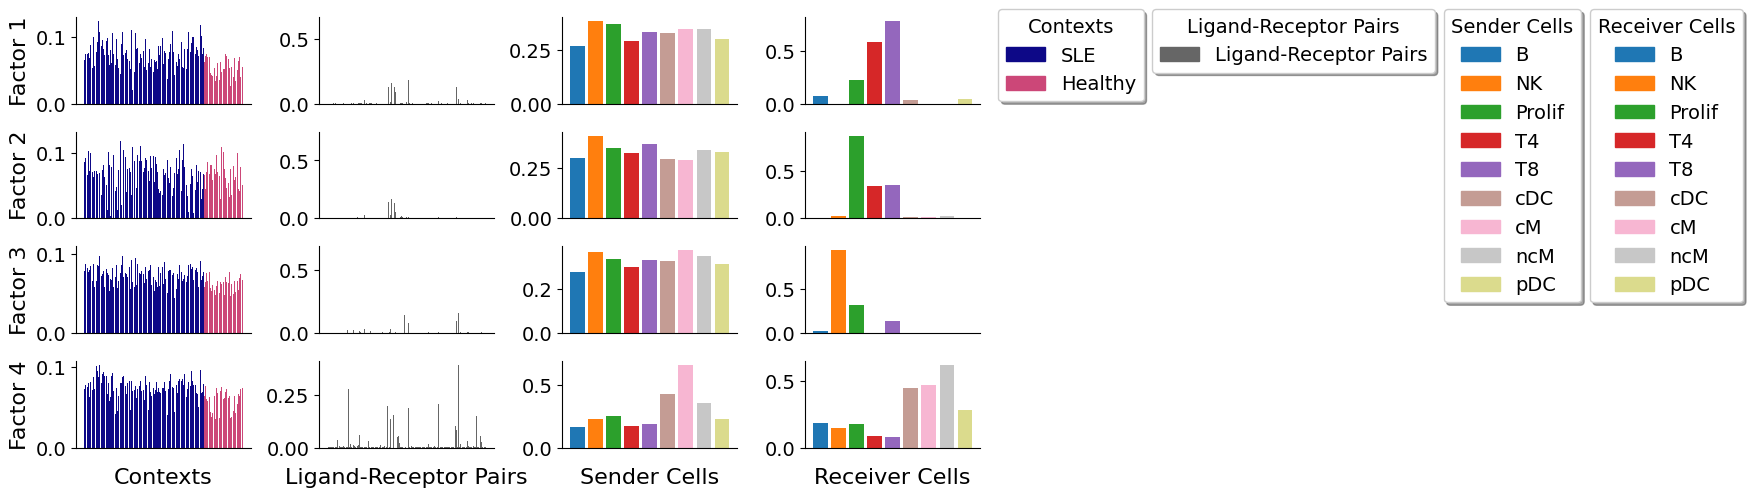

In [3]:
tensor = c2c.analysis.run_tensor_cell2cell_pipeline(tensor,
                                                    meta_tensor,
                                                    rank=4, # Number of factors to perform the factorization. If None, it is automatically determined by an elbow analysis
                                                    tf_optimization='regular', # To define how robust we want the analysis to be.
                                                    random_state=0, # Random seed for reproducibility
                                                    output_fig=True,
                                                    output_folder=out_dir,
                                                    device='cpu')

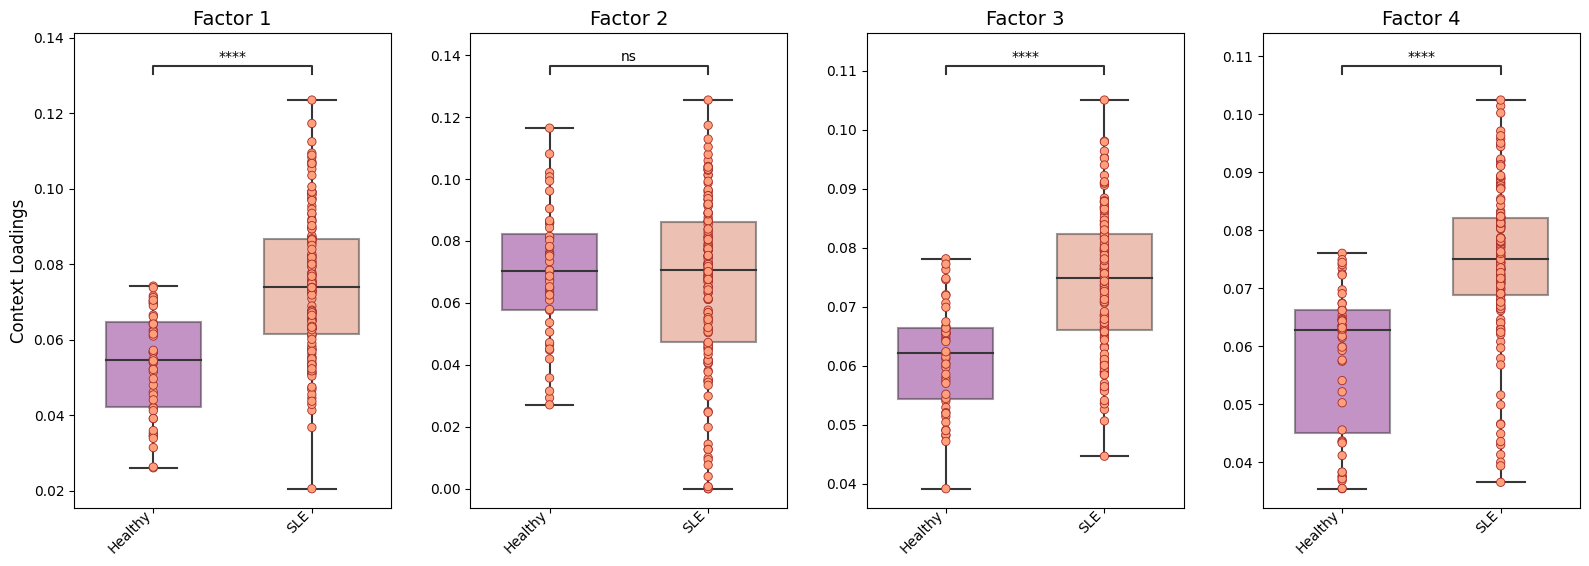

In [4]:
sample_key = "ind_cov"   # must match tensor contexts
group_col  = "SLE_status"

context_dict = meta.set_index(sample_key)[group_col].to_dict()

groups_order = ['Healthy', 'SLE']

_ = c2c.plotting.context_boxplot(context_loadings=tensor.factors['Contexts'],
                                 metadict=context_dict,
                                 nrows=1,
                                 figsize=(16, 6),
                                 group_order=groups_order,
                                 statistical_test='t-test_ind',
                                 pval_correction='fdr_bh',
                                 cmap='plasma',
                                 verbose=False
                                )

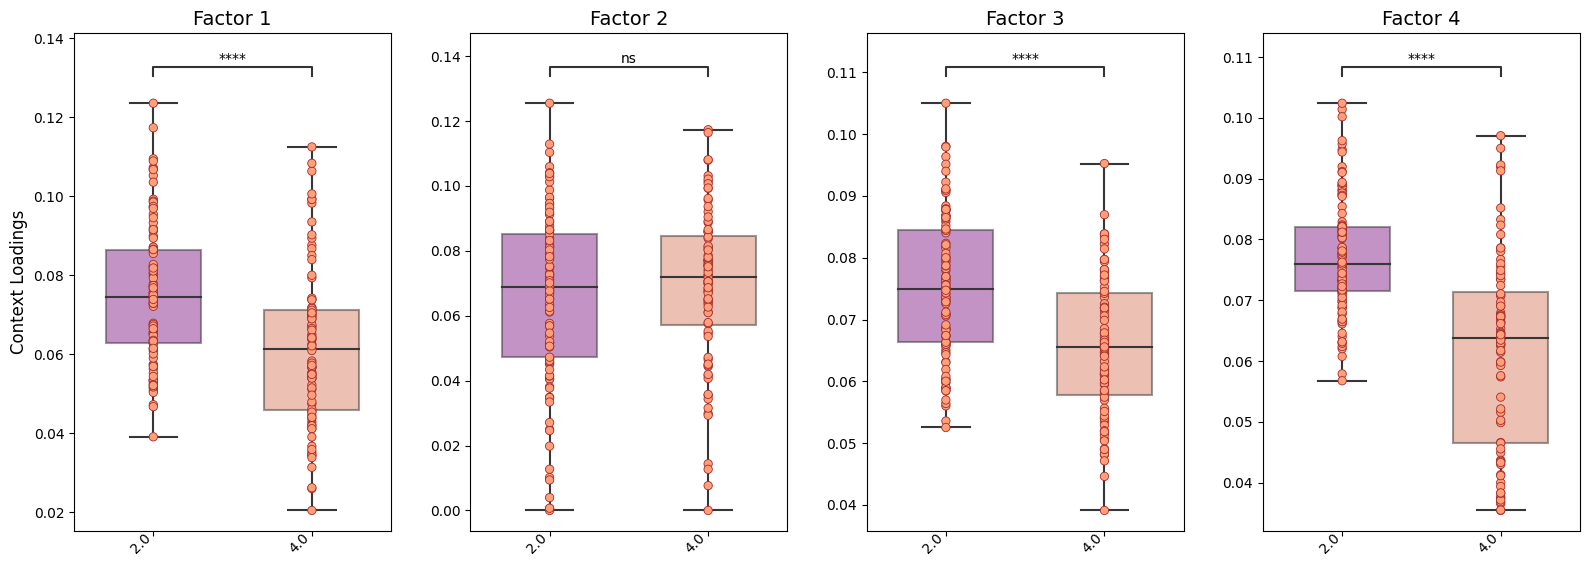

In [5]:
sample_key = "ind_cov"   # must match tensor contexts
group_col  = "Processing_Cohort"

batch_dict = meta.set_index(sample_key)[group_col].to_dict()

_ = c2c.plotting.context_boxplot(context_loadings=tensor.factors['Contexts'],
                                 metadict=batch_dict,
                                 nrows=1,
                                 figsize=(16, 6),
                                 group_order=[2.0, 4.0],
                                 statistical_test='t-test_ind',
                                 pval_correction='fdr_bh',
                                 cmap='plasma',
                                 verbose=False
                                )

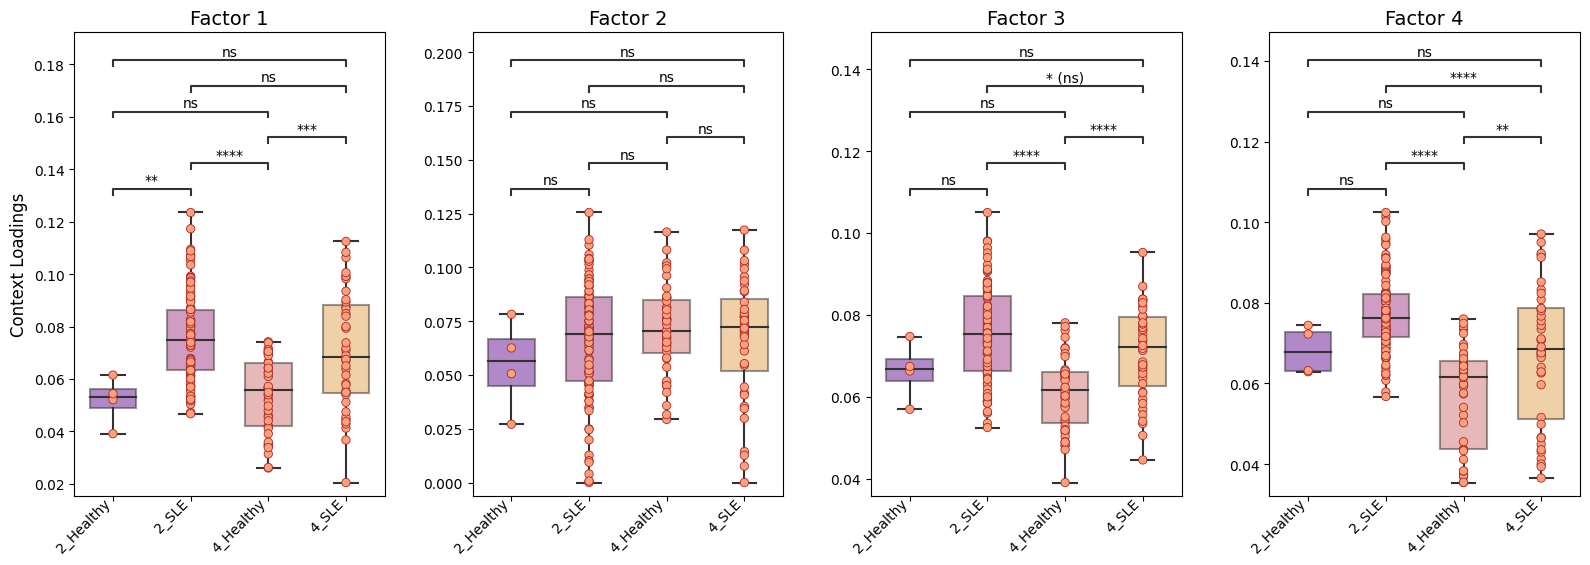

In [6]:
sample_key = "ind_cov"  # must match tensor.factors['Contexts'].index

# Build composite label: e.g., "2_Healthy", "2_SLE", "4_Healthy", "4_SLE"
meta["batch_condition"] = (
    meta["Processing_Cohort"].astype(int).astype(str) + "_" + meta["SLE_status"].astype(str)
)

batch_condition_dict = meta.set_index(sample_key)["batch_condition"].to_dict()

# Ensure every context in the tensor has a label (optional but recommended)
for c in tensor.factors["Contexts"].index:
    if c not in batch_condition_dict:
        batch_condition_dict[c] = "Unknown"

group_order = ["2_Healthy", "2_SLE", "4_Healthy", "4_SLE"]

_ = c2c.plotting.context_boxplot(
    context_loadings=tensor.factors["Contexts"],
    metadict=batch_condition_dict,
    nrows=1,
    figsize=(16, 6),
    group_order=group_order,
    statistical_test="t-test_ind",
    pval_correction="fdr_bh",
    cmap="plasma",
    verbose=False
)

In [7]:
import pandas as pd

# Define base directory
factors = tensor.factors 

# Save each factor with its labels (they're already DataFrames with row/column names)
factors['Contexts'].to_csv(f'{out_dir}/context_loadings.csv')
factors['Ligand-Receptor Pairs'].to_csv(f'{out_dir}/interaction_loadings.csv')
factors['Sender Cells'].to_csv(f'{out_dir}/sender_loadings.csv')
factors['Receiver Cells'].to_csv(f'{out_dir}/receiver_loadings.csv')

print("Saved all factor loadings!")

Saved all factor loadings!
